In [ ]:
# MIND Dataset Exploration (Jupyter Notebook)

## Setup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Paths to data files
behaviors_path = "/Users/joseandres/Library/CloudStorage/OneDrive-ScientificNetworkSouthTyrol/Thesis/Datasets/MIND/SmallMind/MINDSmall_train/behaviors.tsv"
news_path = "/Users/joseandres/Library/CloudStorage/OneDrive-ScientificNetworkSouthTyrol/Thesis/Datasets/MIND/SmallMind/MINDSmall_train/news.tsv"

# Load data
behaviors_df = pd.read_csv(behaviors_path, sep='\t', header=None, names=[
    "impression_id", "user_id", "timestamp", "history", "impressions"
])
news_df = pd.read_csv(news_path, sep='\t', header=None, names=[
    "news_id", "category", "subcategory", "title", "abstract", 
    "url", "title_entities", "abstract_entities"
])



In [2]:
## Preview data
display(behaviors_df.head())
display(news_df.head())


,impression_id,user_id,timestamp,history,impressions
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...


,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ..."
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI..."


In [3]:

## Basic statistics
print("Number of users:", behaviors_df['user_id'].nunique())
print("Number of impressions:", len(behaviors_df))
print("Number of news articles:", news_df['news_id'].nunique())
print("Categories:", news_df['category'].unique())



Number of users: 50000
Number of impressions: 156965
Number of news articles: 51282
Categories: ['lifestyle' 'health' 'news' 'sports' 'weather' 'entertainment' 'autos'
 'travel' 'foodanddrink' 'tv' 'finance' 'movies' 'video' 'music' 'kids'
 'middleeast' 'northamerica']


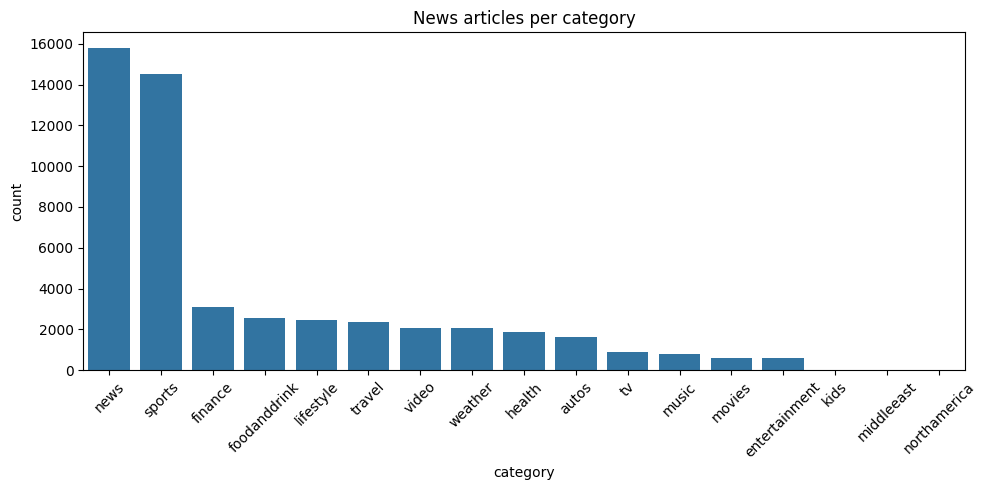

In [4]:

## Distribution of news articles by category
plt.figure(figsize=(10, 5))
sns.countplot(data=news_df, x='category', order=news_df['category'].value_counts().index)
plt.title("News articles per category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


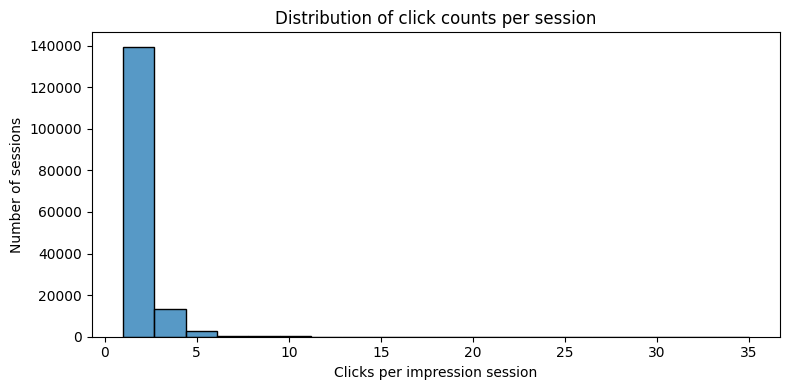

In [5]:

## Click behavior analysis
def count_clicks(impressions_str):
    return sum(int(i.split('-')[1]) for i in impressions_str.split())

behaviors_df['click_count'] = behaviors_df['impressions'].apply(count_clicks)

plt.figure(figsize=(8, 4))
sns.histplot(behaviors_df['click_count'], bins=20, kde=False)
plt.title("Distribution of click counts per session")
plt.xlabel("Clicks per impression session")
plt.ylabel("Number of sessions")
plt.tight_layout()
plt.show()


In [ ]:
## Top clicked news articles
from collections import Counter

all_clicks = []
for imp in behaviors_df['impressions']:
    all_clicks.extend([i.split('-')[0] for i in imp.split() if i.endswith('-1')])

click_counter = Counter(all_clicks)
top_clicks = pd.DataFrame(click_counter.most_common(10), columns=['news_id', 'click_count'])
top_clicks = top_clicks.merge(news_df[['news_id', 'title']], on='news_id')

print("Top Clicked Articles:")
display(top_clicks)

Top Clicked Articles:


,news_id,click_count,title
0,N55689,4316,"Charles Rogers, former Michigan State football..."
1,N35729,3346,Porsche launches into second story of New Jers...
2,N33619,3246,College gymnast dies following training accide...
3,N53585,2835,"Rip Taylor's Cause of Death Revealed, Memorial..."
4,N63970,2578,Dean Foods files for bankruptcy
5,N49685,2294,Broadway Star Laurel Griggs Suffered Asthma At...
6,N49279,2270,Broadway Actress Laurel Griggs Dies at Age 13
7,N287,2128,Three school workers charged in death of speci...
8,N23446,1930,Prince Harry and Meghan Markle just shared a n...
9,N51048,1875,Rep. Tim Ryan endorses Biden in Democratic pri...
